# EDA — GNN-BERT Music Context

Exploratory analysis of the three datasets used in the project:

| Dataset | Task | What it provides |
|---|---|---|
| **MusicCaps** | 1 | expert captions → top-50 aspect tags (text-only proxy) |
| **GTZAN** | 2 | 1,000 tracks, 10 genres → segment graphs |
| **MagnaTagATune** | 3, 4 | 21,108 clips, 50 tags, text = non-label descriptor tags + title/artist → paired graphs |

All figures are produced from the processed files the pipeline writes; nothing here trains a model.

In [1]:
import os, json, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                       # run from repo root
sys.path.insert(0, "src")
import numpy as np, pandas as pd
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("cwd:", os.getcwd())

cwd: D:\gnn-bert-music-context\gnn-bert-music-context


## 1  MusicCaps — Task 1 caption → tag proxy

In [2]:
df1 = pd.read_csv("data/processed/musiccaps_task1.csv")
df1["labels"] = df1["labels"].map(json.loads)
vocab = json.load(open("data/processed/label_vocab.json"))
print("clips:", len(df1), "| label vocab size:", len(vocab))
print("split sizes:", df1["split"].value_counts().to_dict())
df1[["ytid", "split", "text", "labels"]].head(3)

clips: 4996 | label vocab size: 50
split sizes: {'train': 3607, 'test': 752, 'val': 637}


,ytid,split,text,labels
0,-0Gj8-vB1q4,train,The low quality recording features a ballad so...,[low quality]
1,-0SdAVK79lg,train,This song features an electric guitar as the m...,"[bass, instrumental, slow tempo]"
2,-0vPFx-wRRI,train,a male voice is singing a melody with changing...,[amateur recording]


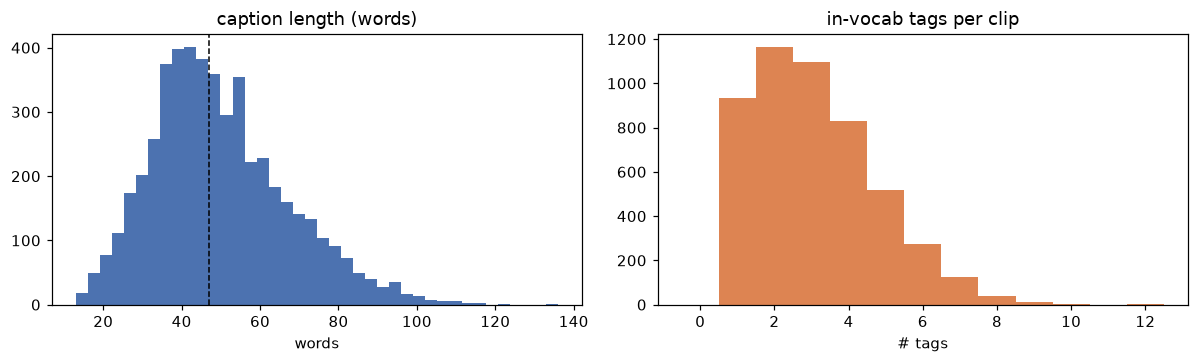

caption words: median 47, mean 49.7, max 136
tags/clip: mean 3.09, median 3


In [3]:
# caption length (word-piece proxy: whitespace tokens) and tags-per-clip
cap_len = df1["text"].str.split().map(len)
tags_per = df1["labels"].map(len)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(cap_len, bins=40, color="#4c72b0"); ax[0].set_title("caption length (words)")
ax[0].set_xlabel("words"); ax[0].axvline(cap_len.median(), color="k", ls="--", lw=1)
ax[1].hist(tags_per, bins=range(0, tags_per.max() + 2), color="#dd8452", align="left")
ax[1].set_title("in-vocab tags per clip"); ax[1].set_xlabel("# tags")
plt.tight_layout(); plt.show()
print(f"caption words: median {cap_len.median():.0f}, mean {cap_len.mean():.1f}, max {cap_len.max()}")
print(f"tags/clip: mean {tags_per.mean():.2f}, median {tags_per.median():.0f}")

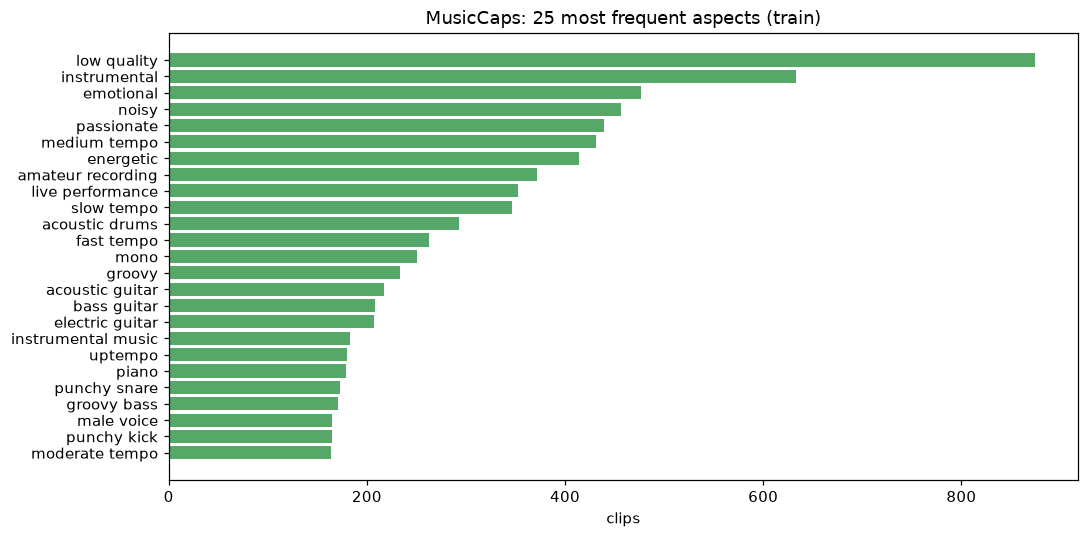

In [4]:
# top-25 aspect frequency (train split)
from collections import Counter
c = Counter(t for ls in df1.loc[df1.split == "train", "labels"] for t in ls)
top = c.most_common(25)
plt.figure(figsize=(10, 5))
plt.barh([t for t, _ in top][::-1], [n for _, n in top][::-1], color="#55a868")
plt.title("MusicCaps: 25 most frequent aspects (train)"); plt.xlabel("clips"); plt.tight_layout(); plt.show()

### Label-in-caption leakage

MusicCaps aspects were written by the same annotator as the caption, so many appear **verbatim** in the text.
This is why Task 1 is reported both unmasked and with those spans deleted (`--mask-aspects`).

In [5]:
def appears_verbatim(row):
    t = row["text"].lower()
    return np.mean([tag.lower() in t for tag in row["labels"]]) if row["labels"] else np.nan

frac = df1.apply(appears_verbatim, axis=1)
print(f"share of a clip's true tags that occur verbatim in its caption: "
      f"mean {np.nanmean(frac):.1%}, median {np.nanmedian(frac):.1%}")

share of a clip's true tags that occur verbatim in its caption: mean 62.0%, median 66.7%


## 2  GTZAN — Task 2 genre classification

tracks: 1000 | splits: {'train': 700, 'test': 150, 'val': 150}


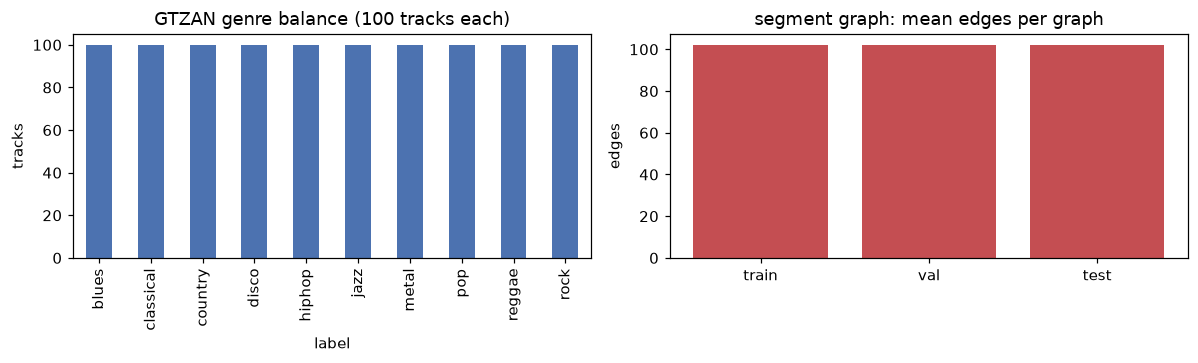

segment graphs: 11 nodes each, ~102 edges, mean degree 9.3


In [6]:
idx2 = pd.read_csv("data/processed/task2_index_gtzan.csv")
print("tracks:", len(idx2), "| splits:", idx2["split"].value_counts().to_dict())
gs = json.load(open("results/metrics/task2_graph_stats.json"))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
idx2["label"].value_counts().sort_index().plot.bar(ax=ax[0], color="#4c72b0")
ax[0].set_title("GTZAN genre balance (100 tracks each)"); ax[0].set_ylabel("tracks")
splits = list(gs); ax[1].bar(splits, [gs[s]["edges_mean"] for s in splits], color="#c44e52")
ax[1].set_title("segment graph: mean edges per graph"); ax[1].set_ylabel("edges")
plt.tight_layout(); plt.show()
print("segment graphs: 11 nodes each,",
      f"~{gs['train']['edges_mean']:.0f} edges, mean degree {gs['train']['mean_degree']:.1f}")

## 3  MagnaTagATune — Tasks 3 & 4 paired data

In [7]:
import torch
blob = torch.load("data/processed/fusion/task3_fusion_magnatagatune.pt", map_location="cpu", weights_only=False)
idx3 = pd.DataFrame(blob["index"]); vocab3 = blob["label_vocab"]
print("paired clips:", len(idx3), "| node_dim:", blob["node_dim"], "| tags:", len(vocab3))
print("splits:", idx3["split"].value_counts().to_dict())
idx3[["track_id", "split", "text", "labels"]].head(3)

paired clips: 21108 | node_dim: 83 | tags: 50
splits: {'train': 15247, 'test': 4332, 'val': 1529}


,track_id,split,text,labels
0,2,test,Artist: American Bach Soloists. Album: J.S. Ba...,"[classical, strings, violin, opera]"
1,6,test,'BWV54 - I Aria' by American Bach Soloists. A ...,"[classical, strings, violin, opera, classic]"
2,10,test,Artist: American Bach Soloists. Album: J.S. Ba...,"[classical, opera, classic]"


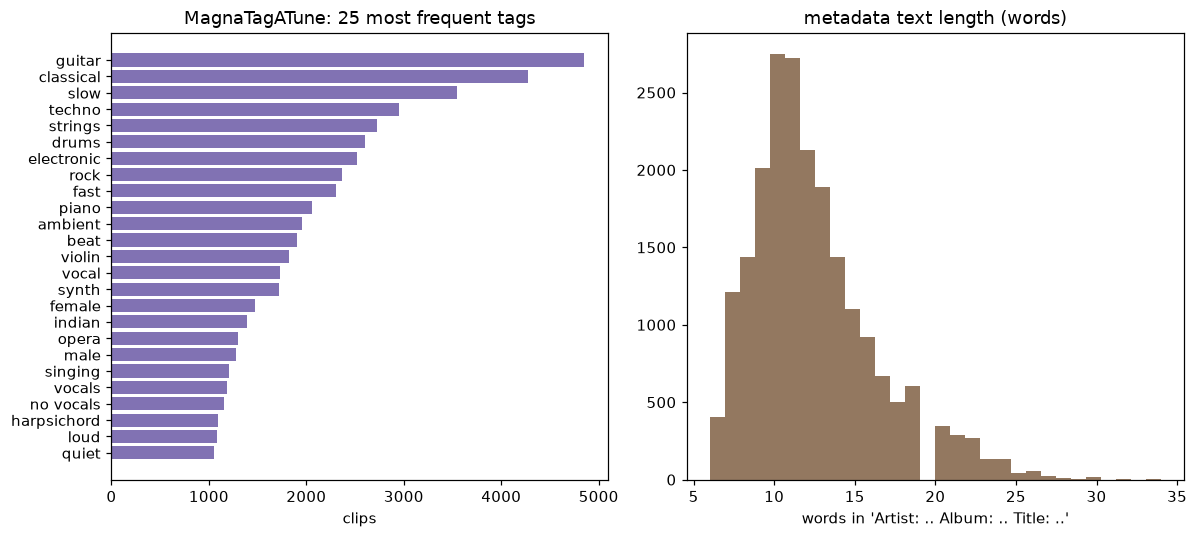

metadata text: median 12 words vs. MusicCaps caption median 47 words  <-- the modality gap behind the Task 3/4 results


In [8]:
# tag frequency + metadata-text length
c3 = Counter(t for ls in idx3["labels"] for t in ls)
top3 = c3.most_common(25)
txtlen = idx3["text"].str.split().map(len)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].barh([t for t, _ in top3][::-1], [n for _, n in top3][::-1], color="#8172b3")
ax[0].set_title("MagnaTagATune: 25 most frequent tags"); ax[0].set_xlabel("clips")
ax[1].hist(txtlen, bins=30, color="#937860"); ax[1].set_title("metadata text length (words)")
ax[1].set_xlabel("words in 'Artist: .. Album: .. Title: ..'")
plt.tight_layout(); plt.show()
print(f"metadata text: median {txtlen.median():.0f} words vs. MusicCaps caption median "
      f"{cap_len.median():.0f} words  <-- the modality gap behind the Task 3/4 results")

graphs: 21108 | nodes mean 19.0 (min 19, max 19) | edges mean 153


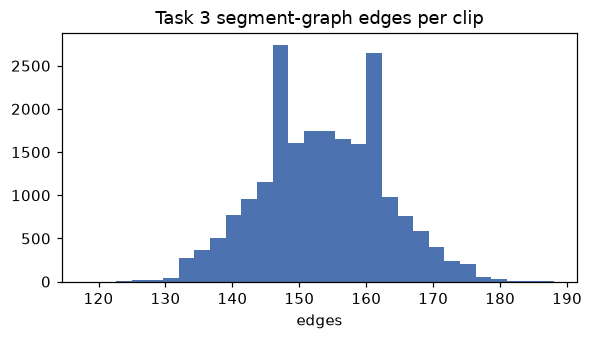

In [9]:
# graph size distribution across the paired set
ncs = np.array([g.num_nodes for g in blob["graphs"].values()])
ecs = np.array([g.edge_index.shape[1] for g in blob["graphs"].values()])
print(f"graphs: {len(ncs)} | nodes mean {ncs.mean():.1f} (min {ncs.min()}, max {ncs.max()}) "
      f"| edges mean {ecs.mean():.0f}")
plt.figure(figsize=(5.5, 3.2)); plt.hist(ecs, bins=30, color="#4c72b0")
plt.title("Task 3 segment-graph edges per clip"); plt.xlabel("edges"); plt.tight_layout(); plt.show()

## 4  Cross-dataset summary

In [10]:
summary = pd.DataFrame([
    ["MusicCaps (Task 1)", len(df1), len(vocab), f"{cap_len.median():.0f}", f"{tags_per.mean():.1f}"],
    ["GTZAN (Task 2)", len(idx2), 10, "n/a (audio)", "1 (single-label)"],
    ["MagnaTagATune (Task 3/4)", len(idx3), len(vocab3), f"{txtlen.median():.0f}", f"{idx3['labels'].map(len).mean():.1f}"],
], columns=["dataset", "clips", "labels", "median text words", "mean tags/clip"])
summary

,dataset,clips,labels,median text words,mean tags/clip
0,MusicCaps (Task 1),4996,50,47,3.1
1,GTZAN (Task 2),1000,10,n/a (audio),1 (single-label)
2,MagnaTagATune (Task 3/4),21108,50,12,3.3


**Takeaway.** MagnaTagATune's synthesised text (non-label descriptor tags +
title/artist, ~39% of clips get real descriptors) still carries far fewer words
than a MusicCaps caption. Tasks 3 and 4 run on MagnaTagATune (MusicCaps audio is
unobtainable — see `results/metrics/musiccaps_download_log.json`); rebuilding this
text from descriptor tags rather than bare metadata is what lifted the Task 3/4
text modality (see `RESULTS.md`).